In [1]:
import scanpy as sc
import os

import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import torch
import torchsde
from torchdyn.core import NeuralODE
import phate
import sys
from tqdm import tqdm
sys.path.insert(0, os.path.abspath("../torch-cfm"))
import importlib

# Import the modules themselves
import torchcfm.conditional_flow_matching as cfm
import torchcfm.models as models
import torchcfm.utils as utils
from torchcfm.conditional_flow_matching import *
from torchcfm.models import MLP
from torchcfm.utils import plot_trajectories, torch_wrapper

## Mostly following the example notebook

Understanding drosophilia data

In [2]:
dr_test_path = "/home/mcb/users/msandl4/scTimeBench/data/DR/drosophila.h5ad"


In [3]:
adata = sc.read_h5ad(dr_test_path)
adata

AnnData object with n_obs × n_vars = 27386 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'rt_bc', 'cell', 'time', 'percent.mt', 'percent.ribo', 'barn_dro', 'barn_hu', 'barn_mus', 'RNA_snn_res.0.8', 'doublet_score', 'predicted_doublet', 'doublet_cluster', 'seurat_clusters', 'doublet_subcluster', 'RNA_snn_res.0.08', 'lasso_age', 'NNv1_age', 'NNv2_age', 'lasso_shift', 'NNv1_shift', 'NNv2_shift', 'tp', 'n_counts_all', 'timepoint'
    uns: 'log1p'

In [4]:
#Provided example uses phate emebeddings
sc.tl.pca(adata, n_comps=50)
X_phate = phate.PHATE(n_components=2).fit_transform(adata.obsm["X_pca"])
adata.obsm["X_phate"] = X_phate

Calculating PHATE...
  Running PHATE on 27386 observations and 50 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 0.70 seconds.
    Calculating affinities...
    Calculated affinities in 2.19 seconds.
  Calculated graph and diffusion operator in 2.94 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 3.11 seconds.
    Calculating KMeans...
    Calculated KMeans in 2.13 seconds.
  Calculated landmark operator in 5.24 seconds.
  Calculating optimal t...
    Automatically selected t = 26
  Calculated optimal t in 1.00 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.23 seconds.
  Calculating metric MDS...
    SGD-MDS may not have converged: stress changed by -2.9% in final iterations. Consider increasing n_iter or adjusting learning_rate.
  Calculated metric MDS in 2.64 seconds.
Calculated PHATE in 12.99 seconds.


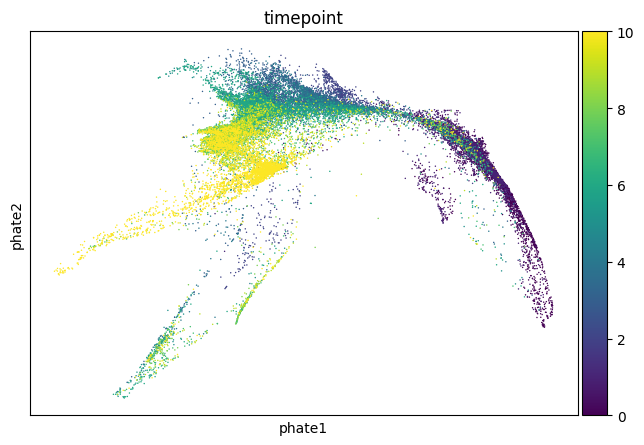

In [5]:
sc.pl.scatter(adata, basis="phate", color="timepoint")

In [6]:
timepoints = sorted(adata.obs["timepoint"].unique())
timepoints

[np.float64(0.0),
 np.float64(1.0),
 np.float64(2.0),
 np.float64(3.0),
 np.float64(4.0),
 np.float64(5.0),
 np.float64(6.0),
 np.float64(7.0),
 np.float64(8.0),
 np.float64(9.0),
 np.float64(10.0)]

In [7]:
n_times = len(timepoints)
# Standardize coordinates
coords = adata.obsm["X_phate"]
coords = (coords - coords.mean(axis=0)) / coords.std(axis=0)
adata.obsm["X_phate_standardized"] = coords

X = [
    adata.obsm["X_phate_standardized"][adata.obs["timepoint"] == t]
    for t in timepoints
]

In [8]:
## from example notebook
import scprep


def plot_trajectories(traj, legend=True):
    n = 2000
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    scprep.plot.scatter(
        adata.obsm["X_phate_standardized"][:, 0],
        adata.obsm["X_phate_standardized"][:, 1],
        title = "CFM trajectories",
        c=adata.obs["timepoint"],
        ax=ax,
    )
    # ax.scatter(traj[0, :n, 0], traj[0, :n, 1], s=10, alpha=0.8, c="black")
    ax.scatter(traj[:, :n, 0], traj[:, :n, 1], s=0.4, alpha=0.1, c="olive")
    # ax.scatter(traj[-1, :n, 0], traj[-1, :n, 1], s=4, alpha=1, c="blue")

    for i in range(15):
        ax.plot(traj[:, i, 0], traj[:, i, 1], alpha=0.9, c="red")
    if legend:
        plt.legend([r"$p_0$", r"$p_t$", r"$p_1$", r"$X_t \mid X_0$"])
    # plt.xticks([])
    # plt.yticks([])
    # plt.axis("off")


def get_batch(FM, X, batch_size, n_times, return_noise=False):
    """Construct a batch with point sfrom each timepoint pair"""
    ts = []
    xts = []
    uts = []
    noises = []
    for t_start in range(n_times - 1):
        x0 = (
            torch.from_numpy(X[t_start][np.random.randint(X[t_start].shape[0], size=batch_size)])
            .float()
            .to(device)
        )
        x1 = (
            torch.from_numpy(
                X[t_start + 1][np.random.randint(X[t_start + 1].shape[0], size=batch_size)]
            )
            .float()
            .to(device)
        )
        if return_noise:
            t, xt, ut, eps = FM.sample_location_and_conditional_flow(
                x0, x1, return_noise=return_noise
            )
            noises.append(eps)
        else:
            t, xt, ut = FM.sample_location_and_conditional_flow(x0, x1, return_noise=return_noise)
        ts.append(t + t_start)
        xts.append(xt)
        uts.append(ut)
    t = torch.cat(ts)
    xt = torch.cat(xts)
    ut = torch.cat(uts)
    if return_noise:
        noises = torch.cat(noises)
        return t, xt, ut, noises
    return t, xt, ut

In [9]:
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
batch_size = 256

In [10]:
def train_model(ot_cfm_optimizer, FM, batch_size, n_times, X, ot_cfm_model, max_iters=10000):
    for i in tqdm(range(10000)):
        ot_cfm_optimizer.zero_grad()
        t, xt, ut = get_batch(FM, X, batch_size, n_times)
        vt = ot_cfm_model(torch.cat([xt, t[:, None]], dim=-1))
        loss = torch.mean((vt - ut) ** 2)
        loss.backward()
        ot_cfm_optimizer.step()

In [11]:
def plot_node_path(ot_cfm_model, X):
    node = NeuralODE(torch_wrapper(ot_cfm_model), solver="dopri5", sensitivity="adjoint")
    with torch.no_grad():
        traj = node.trajectory(
            torch.from_numpy(X[0][:1000]).float().to(device),
            t_span=torch.linspace(0, n_times - 1, 400),
        ).cpu()
        plot_trajectories(traj.cpu().numpy())

## Run Exact

In [12]:

sigma = 0.2
dim = adata.obsm["X_phate_standardized"].shape[1] 
ot_cfm_model = MLP(dim=dim, time_varying=True, w=64).to(device)
ot_cfm_optimizer = torch.optim.Adam(ot_cfm_model.parameters(), 1e-4)
FM = ExactOptimalTransportConditionalFlowMatcher(sigma=sigma, method="exact")

In [13]:
train_model(ot_cfm_optimizer, FM, batch_size, n_times, X, ot_cfm_model, max_iters=10000)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [15:44<00:00, 10.59it/s]


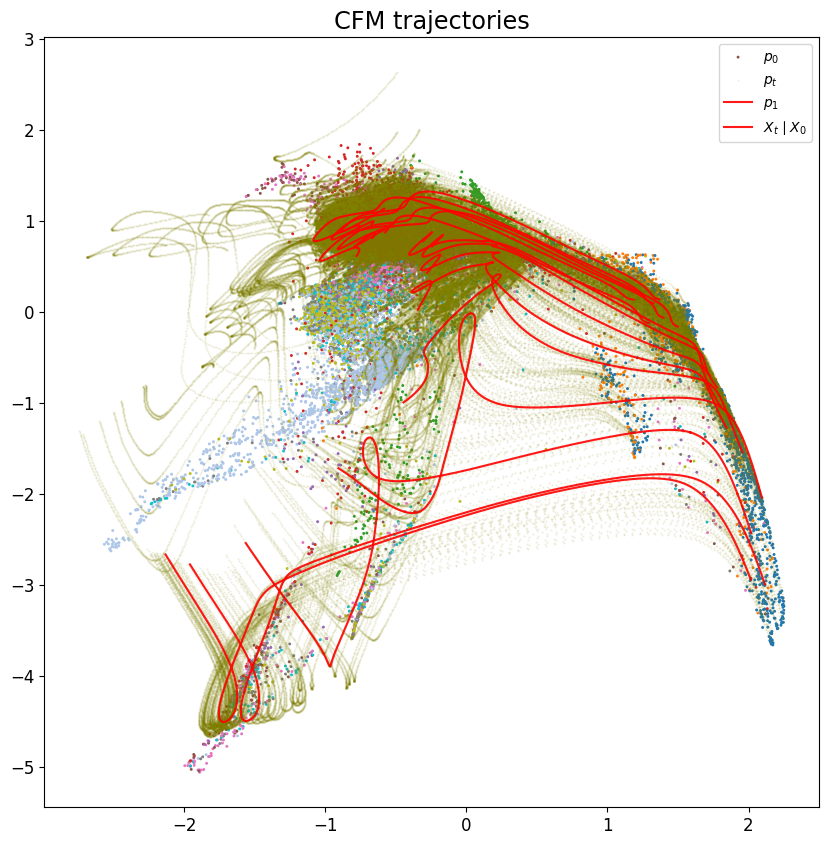

In [14]:
plot_node_path(ot_cfm_model, X)

## Run prior regularization that converges to sinkhorn

In [15]:
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
batch_size = 256
sigma = 0.3
dim = adata.obsm["X_phate_standardized"].shape[1] 
ot_cfm_model = MLP(dim=dim, time_varying=True, w=64).to(device)
ot_cfm_optimizer = torch.optim.Adam(ot_cfm_model.parameters(), 1e-4)
FM = ExactOptimalTransportConditionalFlowMatcher(sigma=sigma, method="prior", prior_method="basic_entropic_ot")

In [16]:
train_model(ot_cfm_optimizer, FM, batch_size, n_times, X, ot_cfm_model, max_iters=10000)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [05:59<00:00, 27.82it/s]


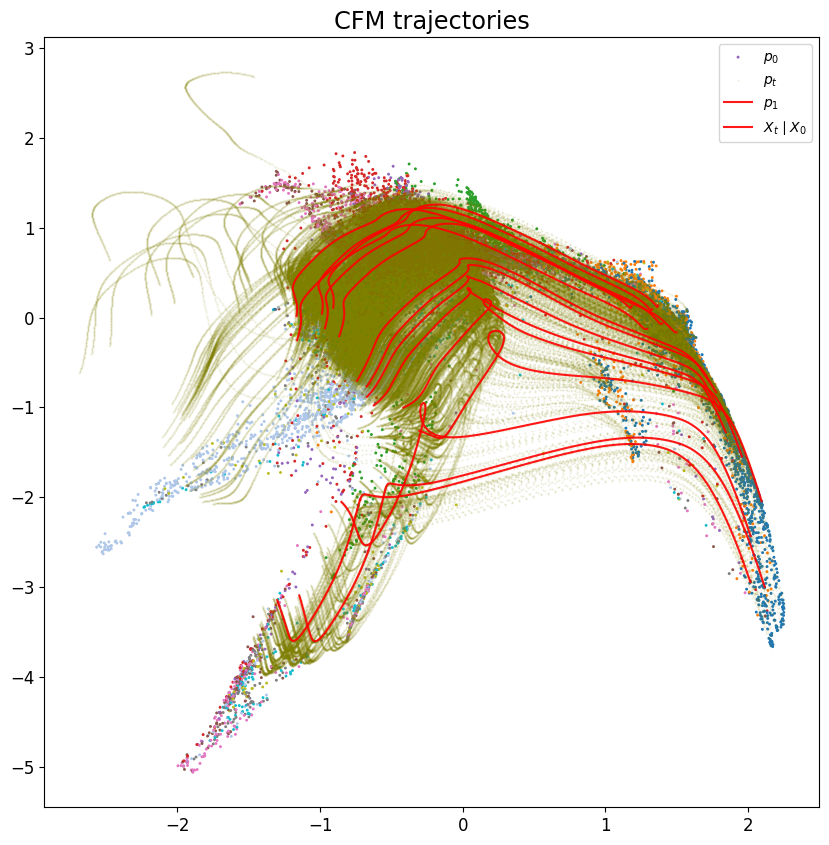

In [17]:
plot_node_path(ot_cfm_model, X)

## Run prior regularization to first (should have worse, but not absoluterly terrible transport trajectory) 

In [20]:
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
batch_size = 256
sigma = 0.1
dim = adata.obsm["X_phate_standardized"].shape[1] 
ot_cfm_model = MLP(dim=dim, time_varying=True, w=64).to(device)
ot_cfm_optimizer = torch.optim.Adam(ot_cfm_model.parameters(), 1e-4)
FM = ExactOptimalTransportConditionalFlowMatcher(sigma=sigma, method="prior", prior_method="to_first")
train_model(ot_cfm_optimizer, FM, batch_size, n_times, X, ot_cfm_model, max_iters=10000)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [05:56<00:00, 28.06it/s]


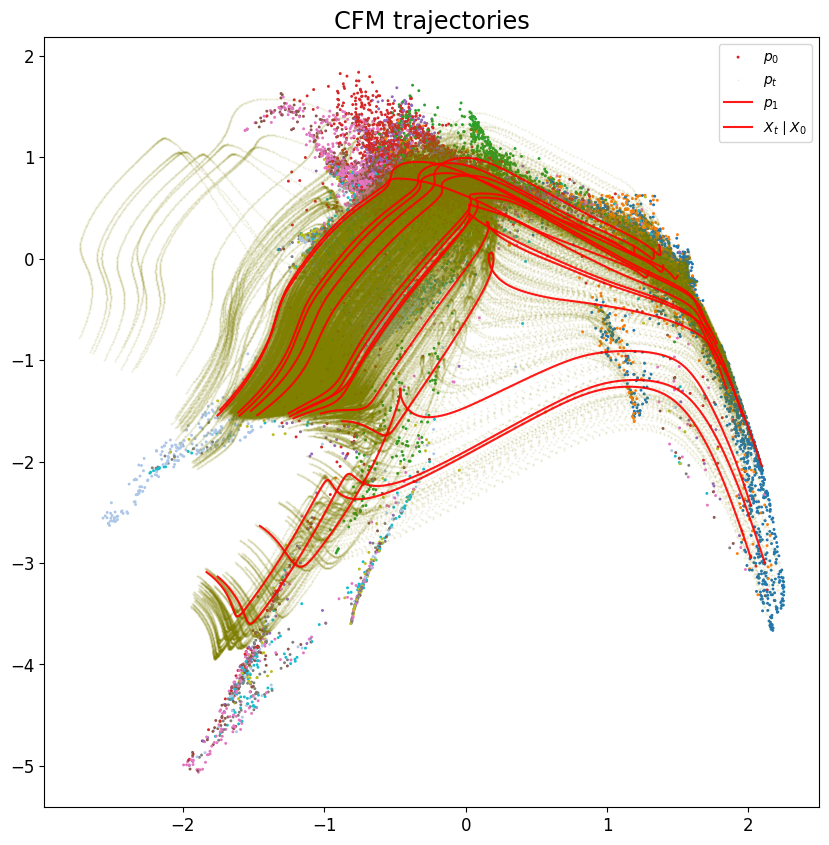

In [19]:
plot_node_path(ot_cfm_model, X)

In [21]:
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
batch_size = 256
sigma = 0.9
dim = adata.obsm["X_phate_standardized"].shape[1] 
ot_cfm_model = MLP(dim=dim, time_varying=True, w=64).to(device)
ot_cfm_optimizer = torch.optim.Adam(ot_cfm_model.parameters(), 1e-4)
FM = ExactOptimalTransportConditionalFlowMatcher(sigma=sigma, method="prior", prior_method="to_first")
train_model(ot_cfm_optimizer, FM, batch_size, n_times, X, ot_cfm_model, max_iters=10000)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [06:04<00:00, 27.46it/s]


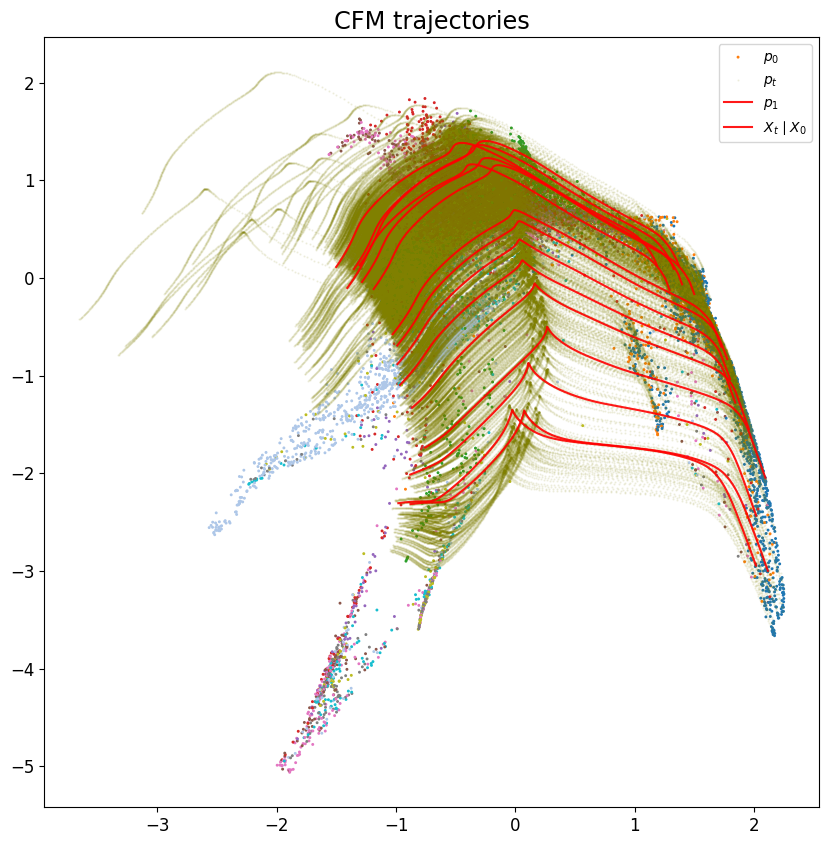

In [22]:
plot_node_path(ot_cfm_model, X)

Stronger to first prior would imply all trajectories look a lot more similar